# Face Blur Ablation Study
Investigates how memorability scores change when facial details are removed.
Compares paired original vs. blurred images through the trained ResNet50 memorability model.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
if not os.path.exists('/content/STATUN3106-image-memorability'):
    !git clone https://github.com/beccangruenberg/STATUN3106-image-memorability.git /content/STATUN3106-image-memorability
else:
    !git -C /content/STATUN3106-image-memorability pull


# ── DEPENDENCIES ────────────────────────────────────────────────────
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import timm
from PIL import Image
from torchvision import transforms
from scipy import stats

# ── PATHS ────────────────────────────────────────────────────────────
# Update DATA_PATH to match your Drive location
DATA_PATH    = "/content/drive/MyDrive/STATUN3106 - Applied Machine Learning/Final Project/STATUN3106_Final_Project/Public/final_submission"
CHECKPOINT   = f"{DATA_PATH}/checkpoints/050626_215834_model_epoch3.pth"   # <-- update
ORIG_DIR     = f"{DATA_PATH}/data/lamem_final"         # <-- update if needed
BLURRED_DIR  = f"{DATA_PATH}/data/ablation_face_blur"          # <-- update if needed
RESULTS_DIR  = f"{DATA_PATH}/results/blur"
os.makedirs(RESULTS_DIR, exist_ok=True)

Mounted at /content/drive
Cloning into '/content/STATUN3106-image-memorability'...
remote: Enumerating objects: 226, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 226 (delta 0), reused 2 (delta 0), pack-reused 222 (from 1)
Receiving objects: 100% (226/226), 1.74 MiB | 4.56 MiB/s, done.
Resolving deltas: 100% (95/95), done.


In [4]:
# ── VALIDATE PATHS ───────────────────────────────────────────────────
import os

paths_to_check = {
    "Checkpoint":   CHECKPOINT,
    "Original dir": ORIG_DIR,
    "Blurred dir":  BLURRED_DIR,
    "Results dir":  RESULTS_DIR,
}

all_ok = True
for label, path in paths_to_check.items():
    exists = os.path.exists(path)
    status = "✅" if exists else "❌  NOT FOUND"
    print(f"{status}  {label}: {path}")
    if not exists:
        all_ok = False

# Count images in each image directory
for label, dirpath in [("Original dir", ORIG_DIR), ("Blurred dir", BLURRED_DIR)]:
    if os.path.isdir(dirpath):
        imgs = [f for f in os.listdir(dirpath) if f.lower().endswith(('.jpg','.jpeg','.png'))]
        print(f"   └─ {len(imgs)} images found")

print()
if all_ok:
    print("All paths valid — safe to proceed.")
else:
    print("Fix the missing paths above before continuing.")
    raise FileNotFoundError("One or more required paths are missing.")

✅  Checkpoint: /content/drive/MyDrive/STATUN3106 - Applied Machine Learning/Final Project/STATUN3106_Final_Project/Public/final_submission/checkpoints/050626_215834_model_epoch3.pth
✅  Original dir: /content/drive/MyDrive/STATUN3106 - Applied Machine Learning/Final Project/STATUN3106_Final_Project/Public/final_submission/data/lamem_final
✅  Blurred dir: /content/drive/MyDrive/STATUN3106 - Applied Machine Learning/Final Project/STATUN3106_Final_Project/Public/final_submission/data/ablation_face_blur
✅  Results dir: /content/drive/MyDrive/STATUN3106 - Applied Machine Learning/Final Project/STATUN3106_Final_Project/Public/final_submission/results/blur
   └─ 1000 images found
   └─ 999 images found

All paths valid — safe to proceed.


In [5]:
# ── MODEL ────────────────────────────────────────────────────────────
class MemorabilityModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model('resnet50', pretrained=False, num_classes=0)
        self.regressor = nn.Sequential(
            nn.Linear(2048, 512), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 1), nn.Sigmoid()
        )
    def forward(self, x):
        return self.regressor(self.backbone(x)).squeeze()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = MemorabilityModel().to(device)
model.load_state_dict(torch.load(CHECKPOINT, map_location=device))
model.eval()
print(f"Model loaded on: {device}")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def predict_score(pil_img):
    with torch.no_grad():
        t = transform(pil_img).unsqueeze(0).to(device)
        return model(t).item()

Model loaded on: cuda


In [7]:
# ── SCORE ALL PAIRS ──────────────────────────────────────────────────
filenames = sorted([
    f for f in os.listdir(ORIG_DIR)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
])

results = []
for fname in filenames:
    blurred_path = os.path.join(BLURRED_DIR, fname)
    if not os.path.exists(blurred_path):
        continue
    orig    = Image.open(os.path.join(ORIG_DIR, fname)).convert('RGB')
    blurred = Image.open(blurred_path).convert('RGB')
    s_orig  = predict_score(orig)
    s_blur  = predict_score(blurred)
    results.append({'filename': fname, 'original': s_orig,
                    'blurred': s_blur, 'delta': s_blur - s_orig})

df = pd.DataFrame(results)
print(f"Pairs evaluated: {len(df)}")
print(df[['original','blurred','delta']].describe().round(4))
df.to_csv(f"{RESULTS_DIR}/blur_scores.csv", index=False)
print("Saved: blur_scores.csv")

Pairs evaluated: 999
       original   blurred     delta
count  999.0000  999.0000  999.0000
mean     0.7360    0.7354   -0.0007
std      0.0855    0.0848    0.0183
min      0.5166    0.5161   -0.1241
25%      0.6716    0.6714   -0.0064
50%      0.7381    0.7389    0.0004
75%      0.7986    0.7979    0.0075
max      0.9460    0.9461    0.0940
Saved: blur_scores.csv


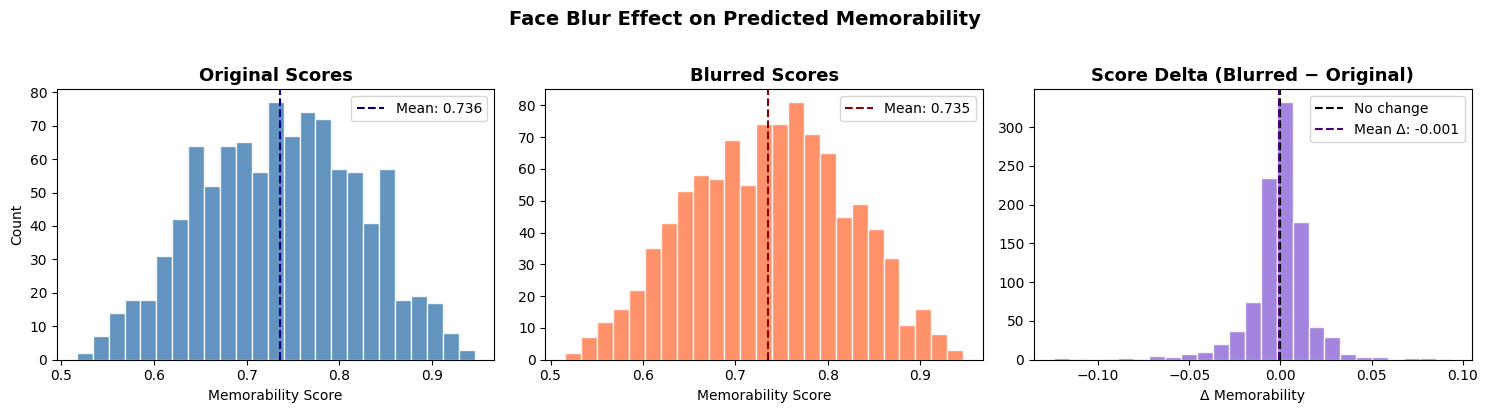

In [8]:
# ── FIGURE 1: Score distributions ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['original'], bins=25, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Original Scores', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Memorability Score'); axes[0].set_ylabel('Count')
axes[0].axvline(df['original'].mean(), color='navy', linestyle='--', label=f"Mean: {df['original'].mean():.3f}")
axes[0].legend()

axes[1].hist(df['blurred'], bins=25, color='coral', edgecolor='white', alpha=0.85)
axes[1].set_title('Blurred Scores', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Memorability Score')
axes[1].axvline(df['blurred'].mean(), color='darkred', linestyle='--', label=f"Mean: {df['blurred'].mean():.3f}")
axes[1].legend()

axes[2].hist(df['delta'], bins=25, color='mediumpurple', edgecolor='white', alpha=0.85)
axes[2].axvline(0, color='black', linestyle='--', linewidth=1.5, label='No change')
axes[2].axvline(df['delta'].mean(), color='indigo', linestyle='--', label=f"Mean Δ: {df['delta'].mean():+.3f}")
axes[2].set_title('Score Delta (Blurred − Original)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Δ Memorability')
axes[2].legend()

plt.suptitle('Face Blur Effect on Predicted Memorability', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/fig1_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

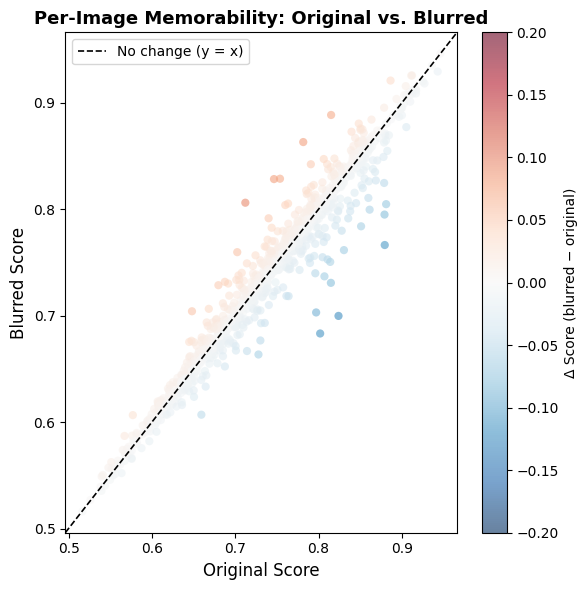

In [9]:
# ── FIGURE 2: Per-image scatter (original vs. blurred) ───────────────
fig, ax = plt.subplots(figsize=(6, 6))
sc = ax.scatter(df['original'], df['blurred'],
                c=df['delta'], cmap='RdBu_r', vmin=-0.2, vmax=0.2,
                alpha=0.6, s=35, edgecolors='none')
lims = [min(df[['original','blurred']].min()) - 0.02,
        max(df[['original','blurred']].max()) + 0.02]
ax.plot(lims, lims, 'k--', linewidth=1.2, label='No change (y = x)')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Original Score', fontsize=12)
ax.set_ylabel('Blurred Score', fontsize=12)
ax.set_title('Per-Image Memorability: Original vs. Blurred', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.colorbar(sc, ax=ax, label='Δ Score (blurred − original)')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/fig2_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

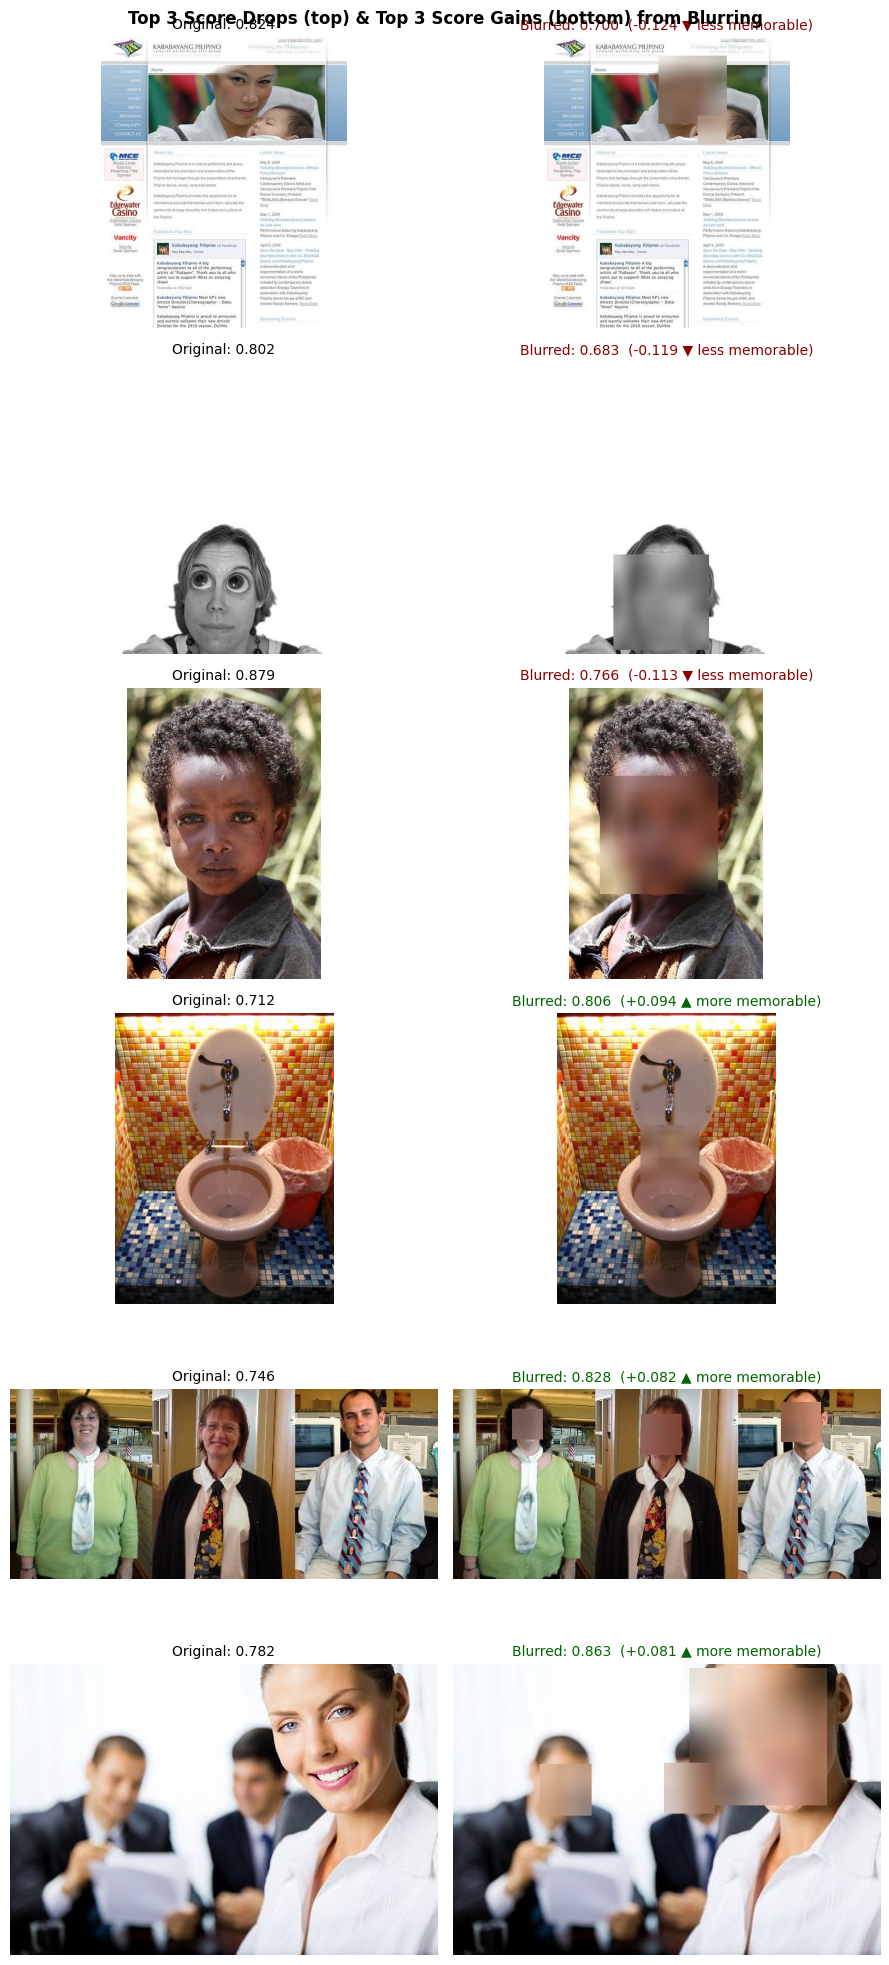

In [10]:
# ── FIGURE 3: Top 6 most-affected pairs (3 biggest drops, 3 biggest gains) ─
top_drops = df.nsmallest(3, 'delta')   # blurring hurt memorability most
top_gains = df.nlargest(3, 'delta')    # blurring helped memorability most
showcase  = pd.concat([top_drops, top_gains])

fig, axes = plt.subplots(6, 2, figsize=(9, 20))
for i, (_, row) in enumerate(showcase.iterrows()):
    orig    = Image.open(os.path.join(ORIG_DIR, row['filename'])).convert('RGB')
    blurred = Image.open(os.path.join(BLURRED_DIR, row['filename'])).convert('RGB')
    color   = 'darkgreen' if row['delta'] > 0 else 'darkred'
    label   = '▲ more memorable' if row['delta'] > 0 else '▼ less memorable'

    axes[i,0].imshow(orig)
    axes[i,0].set_title(f"Original: {row['original']:.3f}", fontsize=10)
    axes[i,0].axis('off')

    axes[i,1].imshow(blurred)
    axes[i,1].set_title(
        f"Blurred: {row['blurred']:.3f}  ({row['delta']:+.3f} {label})",
        fontsize=10, color=color
    )
    axes[i,1].axis('off')

fig.suptitle('Top 3 Score Drops (top) & Top 3 Score Gains (bottom) from Blurring',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/fig3_top_pairs.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# ── STATISTICAL SUMMARY ──────────────────────────────────────────────
t_stat, p_val = stats.ttest_rel(df['original'], df['blurred'])
pct_down = (df['delta'] < 0).mean() * 100
pct_up   = (df['delta'] > 0).mean() * 100

print("=" * 45)
print("FACE BLUR ABLATION — SUMMARY")
print("=" * 45)
print(f"N pairs               : {len(df)}")
print(f"Mean original score   : {df['original'].mean():.4f}  (std {df['original'].std():.4f})")
print(f"Mean blurred score    : {df['blurred'].mean():.4f}  (std {df['blurred'].std():.4f})")
print(f"Mean delta            : {df['delta'].mean():+.4f}  (std {df['delta'].std():.4f})")
print(f"% pairs score dropped : {pct_down:.1f}%")
print(f"% pairs score rose    : {pct_up:.1f}%")
print(f"Paired t-test         : t = {t_stat:.3f},  p = {p_val:.4f}")
sig = "SIGNIFICANT" if p_val < 0.05 else "NOT significant"
print(f"Result                : {sig} at α = 0.05")

FACE BLUR ABLATION — SUMMARY
N pairs               : 999
Mean original score   : 0.7360  (std 0.0855)
Mean blurred score    : 0.7354  (std 0.0848)
Mean delta            : -0.0007  (std 0.0183)
% pairs score dropped : 48.5%
% pairs score rose    : 51.5%
Paired t-test         : t = 1.129,  p = 0.2593
Result                : NOT significant at α = 0.05
